# 00_pipeline_runner.ipynb
Step-by-step pipeline runner (download → alignment → windowing → proxy labels → manifest).


In [8]:
# --- Configuration ---
RUN_ID = '20251111_10scenario'  # e.g., '20251111_bike'
CONFIG_PATH = 'config/default.yaml'

DOWNLOAD_LIMIT = 10
RUN_ANALYZE_CACHE = False
RUN_DOWNLOAD = False
RUN_ALIGNMENT = True
RUN_WINDOWING = True
RUN_WEAK_LABELS = False
RUN_MANIFEST = True
RUN_QA_ANALYSIS = False  # sections 7+
RUN_FEATURE_DIAG = False
RUN_NORMAL_FILTER = False
RUN_SPLIT_PLANNING = False
RUN_SSL_TRAIN = False
RUN_ONECLASS = False
RUN_BOCPD_METRICS = False

from pathlib import Path
NOTEBOOK_DIR = Path().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
RUN_ROOT = REPO_ROOT / 'runs' / RUN_ID
RUN_ROOT.mkdir(parents=True, exist_ok=True)
DATA_AUDIT_DIR = RUN_ROOT / 'notebook_reports' / 'data_audit'
DATA_AUDIT_DIR.mkdir(parents=True, exist_ok=True)
ALIGN_UIDS_FILE = str(RUN_ROOT / 'state' / 'ready_for_alignment.txt')
WINDOW_UIDS_FILE = str(RUN_ROOT / 'state' / 'ready_for_windowing.txt')
DOWNLOAD_UIDS_FILE = str(RUN_ROOT / 'state' / 'download_uids.txt')
print('NOTEBOOK_DIR:', NOTEBOOK_DIR)
print('REPO_ROOT:', REPO_ROOT)
print('RUN_ID:', RUN_ID)
print('RUN_ROOT:', RUN_ROOT)
print('DATA_AUDIT_DIR:', DATA_AUDIT_DIR)
print('ALIGN_UIDS_FILE:', ALIGN_UIDS_FILE)
print('WINDOW_UIDS_FILE:', WINDOW_UIDS_FILE)


NOTEBOOK_DIR: /Users/huangjunda/Desktop/MIT 2.156/Final Project/notebooks
REPO_ROOT: /Users/huangjunda/Desktop/MIT 2.156/Final Project
RUN_ID: 20251111_10scenario
RUN_ROOT: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario
DATA_AUDIT_DIR: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit
ALIGN_UIDS_FILE: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_alignment.txt
WINDOW_UIDS_FILE: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_windowing.txt


In [9]:
import subprocess
from pathlib import Path
NOTEBOOK_DIR_CMD = Path().resolve()
REPO_ROOT_CMD = globals().get('REPO_ROOT', NOTEBOOK_DIR_CMD.parent)
print('run_cmd using repo root:', REPO_ROOT_CMD)

def run_cmd(cmd_list):
    print('Running:', ' '.join(str(x) for x in cmd_list))
    completed = subprocess.run(cmd_list, cwd=REPO_ROOT_CMD)
    if completed.returncode != 0:
        raise RuntimeError(f'Command failed with code {completed.returncode}')


run_cmd using repo root: /Users/huangjunda/Desktop/MIT 2.156/Final Project


## 2. Download modalities (optional)

### 2.1 Setup: Ensure candidate_takes.csv is available


In [10]:
import pandas as pd
import shutil

# Check if candidate_takes.csv exists at project root
candidate_csv = REPO_ROOT / 'candidate_takes.csv'
candidate_csv_state = REPO_ROOT / 'state' / 'active' / 'candidate_takes.csv'

if not candidate_csv.exists():
    # Try to copy from state/active if available
    if candidate_csv_state.exists():
        print(f"📋 Copying candidate_takes.csv from state/active/ to project root...")
        shutil.copy(candidate_csv_state, candidate_csv)
        print(f"✅ Copied to: {candidate_csv}")
    else:
        print(f"❌ Missing: {candidate_csv}")
        print("\nThe candidate_takes.csv file is required but not found.")
        print("\nOptions to resolve:")
        print("1. If you have the file elsewhere, copy it to:")
        print(f"   {candidate_csv}")
        print("\n2. Check if it exists in state/active/:")
        print(f"   {candidate_csv_state}")
        print("\n3. Download EgoExo4D metadata or restore from backup")
        raise FileNotFoundError(f"Required file not found: {candidate_csv}")
else:
    print(f"✅ Found: {candidate_csv}")

# Load and analyze candidate takes
candidate_df = pd.read_csv(candidate_csv)
scenario_counts = (
    candidate_df.groupby('scenario')['take_uid']
    .nunique()
    .sort_values(ascending=False)
)
display(scenario_counts.to_frame('take_count'))

# Select all non-bike scenarios
target_scenarios = [s for s in scenario_counts.index if 'bike' not in s.lower()]
# Pick the ones have more than 3 takes
target_scenarios = [s for s in target_scenarios if scenario_counts[s] > 3]
if not target_scenarios:
    target_scenarios = [
        'assembly', 'kitchen', 'navigation', 'medical',
        'first_aid', 'translation', 'daily_life', 'fall_incident'
    ]

print(f'\n✅ Target scenarios: {len(target_scenarios)} selected')
for i, scenario in enumerate(target_scenarios[:5], 1):
    print(f'  {i}. {scenario} ({scenario_counts[scenario]} takes)')
if len(target_scenarios) > 5:
    print(f'  ... and {len(target_scenarios) - 5} more')


📋 Copying candidate_takes.csv from state/active/ to project root...
✅ Copied to: /Users/huangjunda/Desktop/MIT 2.156/Final Project/candidate_takes.csv


,take_count
scenario,
Covid-19 Rapid Antigen Test,299
Cooking an Omelet,98
Making Cucumber & Tomato Salad,66
Making Milk Tea,64
Clean and Lubricate the Chain,52
Cooking Scrambled Eggs,51
Cooking Tomato & Eggs,49
Install a Wheel,42
Remove a Wheel,33



✅ Target scenarios: 17 selected
  1. Covid-19 Rapid Antigen Test (299 takes)
  2. Cooking an Omelet (98 takes)
  3. Making Cucumber & Tomato Salad (66 takes)
  4. Making Milk Tea (64 takes)
  5. Clean and Lubricate the Chain (52 takes)
  ... and 12 more


In [11]:
import pandas as pd
from pathlib import Path
cand = pd.read_csv(REPO_ROOT / 'candidate_takes.csv')
non_bike = cand[~cand['take_name'].str.contains('bike', case=False, na=False)]
uids_sampled = []
for scenario, group in non_bike.groupby('scenario'):
    sample = group.sample(n=min(10, len(group)), random_state=42)
    uids_sampled.extend(sample['take_uid'])
Path(DOWNLOAD_UIDS_FILE).parent.mkdir(parents=True, exist_ok=True)
Path(DOWNLOAD_UIDS_FILE).write_text('\n'.join(uids_sampled))
print(f'Sampled {len(uids_sampled)} UIDs -> {DOWNLOAD_UIDS_FILE}')


Sampled 131 UIDs -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/download_uids.txt


In [12]:
if RUN_DOWNLOAD:
    uid_lines = Path(DOWNLOAD_UIDS_FILE).read_text().strip().split('\n')
    if not uid_lines:
        raise RuntimeError('DOWNLOAD_UIDS_FILE is empty; generate samples first.')
    run_cmd([
        'python','scripts/download_modalities.py',
        '--config', CONFIG_PATH,
        '--run-root', str(RUN_ROOT),
        '--uids-file', DOWNLOAD_UIDS_FILE,
        '--limit', str(40),
        '--yes'
    ])
else:
    print('Skipping download (set RUN_DOWNLOAD=True).')


Skipping download (set RUN_DOWNLOAD=True).


In [13]:
import json
import pandas as pd
log_files = sorted((RUN_ROOT / "state" / "logs").glob("download_*.json"))
if not log_files:
    raise FileNotFoundError("No download logs under state/logs")
cand = pd.read_csv(REPO_ROOT / "candidate_takes.csv").set_index("take_uid")
uids = []
for batch in json.loads(log_files[-1].read_text()):
    for uid in batch.get("take_uids", []):
        if uid not in cand.index:
            continue
        scenario = cand.loc[uid, "scenario"]
        if "bike" in scenario.lower():
            continue
        uids.append(uid)
out_path = RUN_ROOT / "state" / "ready_for_alignment.txt"
out_path.write_text('\n'.join(uids))
out_path = RUN_ROOT / 'state' / 'ready_for_alignment.txt'
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text('\n'.join(uids))
print('Ready file:', out_path)


Ready file: /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_alignment.txt


## 3. Alignment & QA

In [14]:
if RUN_ALIGNMENT:
    run_cmd([
        'python','scripts/run_alignment.py',
        '--config', CONFIG_PATH,
        '--run-root', str(RUN_ROOT),
        '--uids-file', ALIGN_UIDS_FILE,
        '--overwrite',
    ])
else:
    print('Skipping alignment (set RUN_ALIGNMENT=True to run).')


Running: python scripts/run_alignment.py --config config/default.yaml --run-root /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario --uids-file /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_alignment.txt --overwrite


Matplotlib is building the font cache; this may take a moment.


[1/40] 4d6e4368-543b-4b69-a261-e8c01401ee8c (indiana_cooking_04_3) -> OK
[2/40] 0015e453-3227-41b0-bd64-03c134abe054 (sfu_cooking_013_3) -> OK
[3/40] c726ae4b-d68f-4b59-9c41-47a4615eef51 (indiana_cooking_14_6) -> OK
[4/40] f06d7f9b-0da8-4406-b3d3-06cd70de0e0f (nus_cooking_12_4) -> OK
[5/40] 3cbd7070-7c55-4b15-ac31-100ab8c7298a (fair_cooking_05_2) -> OK
[6/40] f76f2040-989c-42df-b2fb-e0903165443d (sfu_cooking_007_3) -> OK
[7/40] c8a70210-89d2-4b7e-bea7-5a79712fe631 (indiana_cooking_22_5) -> OK
[8/40] b9e252ee-51c4-480d-8dc0-6a0a6022fa0f (indiana_cooking_17_5) -> OK
[9/40] 10114022-4de6-43cd-af19-b3bc5cbeae31 (nus_cooking_07_4) -> OK
[10/40] 53ee9e25-ba9b-429e-9cad-70c223a2f881 (fair_cooking_05_4) -> OK
[11/40] b7f61e87-02ff-4d15-9882-e7816b072765 (sfu_cooking030_6) -> OK
[12/40] 6bc7a29f-3397-4549-9ee2-d98fa93da873 (fair_cooking_06_6) -> OK
[13/40] fffda904-c5bd-4ed2-96b8-0ae518a7c3ec (minnesota_cooking_023_6) -> OK
[14/40] 4773786c-6320-4a24-81e9-d735dbf9476b (minnesota_cooking_040_6) 

## 4. Windowing + feature export

In [15]:
if RUN_WINDOWING:
    run_cmd([
        'python', 'scripts/make_windows.py',
        '--config', CONFIG_PATH,
        '--run-root', RUN_ROOT.as_posix(),
        '--uids-file', WINDOW_UIDS_FILE,
    ])
else:
    print('Skipping windowing (set RUN_WINDOWING=True to run).')


Running: python scripts/make_windows.py --config config/default.yaml --run-root /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario --uids-file /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_windowing.txt
[ok] 4d6e4368-543b-4b69-a261-e8c01401ee8c: 3101 windows -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows/4d6e4368-543b-4b69-a261-e8c01401ee8c
[ok] 0015e453-3227-41b0-bd64-03c134abe054: 2261 windows -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows/0015e453-3227-41b0-bd64-03c134abe054
[ok] c726ae4b-d68f-4b59-9c41-47a4615eef51: 4357 windows -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows/c726ae4b-d68f-4b59-9c41-47a4615eef51
[ok] f06d7f9b-0da8-4406-b3d3-06cd70de0e0f: 2746 windows -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows/f06d7f9b-0da8-4406-b3d3-06cd70de0e0f
[ok] 3cbd707

## 6. Manifest

In [16]:
if RUN_MANIFEST:
    run_cmd([
        'python', 'tools/create_manifest.py',
        '--run-id', RUN_ID,
        '--output-root', 'runs',
        '--uids-file', WINDOW_UIDS_FILE,
        '--window', '3.0',
        '--hop', '0.2',
        '--seq-len', '50',
        '--weak-label-rule', 'linear_angspeed_gazestd_v1',
        '--notes', 'Notebook pipeline run',
    ])
else:
    print('Skipping manifest (set RUN_MANIFEST=True to run).')


Running: python tools/create_manifest.py --run-id 20251111_10scenario --output-root runs --uids-file /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/state/ready_for_windowing.txt --window 3.0 --hop 0.2 --seq-len 50 --weak-label-rule linear_angspeed_gazestd_v1 --notes Notebook pipeline run
Manifest written to runs/20251111_10scenario/manifest.json


## 7. QA & Coverage


In [17]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

qa_dirs = []
run_qa_dir = RUN_ROOT / 'qa'
if run_qa_dir.exists():
    qa_dirs.append(('run', run_qa_dir))
legacy_processed = Path('processed_windows/qa')
if legacy_processed.exists():
    qa_dirs.append(('legacy_processed', legacy_processed))
legacy_outputs = Path('outputs/legacy_run/processed_windows/qa')
if legacy_outputs.exists():
    qa_dirs.append(('legacy_outputs', legacy_outputs))

qa_records = []
for source_name, qa_path in qa_dirs:
    for fp in sorted(qa_path.glob('*.json')):
        try:
            data = json.loads(fp.read_text())
        except json.JSONDecodeError:
            continue
        duration = data.get('duration') or data.get('duration_gaze_s') or {}
        sample_rate = data.get('sample_rate_hz') or data.get('sample_rates_hz') or {}
        missing_ratio = data.get('missing_ratio') or {}
        qa_records.append({
            'qa_source': source_name,
            'take_uid': data.get('take_uid'),
            'take_name': data.get('take_name'),
            'aligned': data.get('aligned'),
            'duration_gaze_s': duration.get('gaze_s') if isinstance(duration, dict) else data.get('duration_gaze_s'),
            'duration_traj_s': duration.get('trajectory_s') if isinstance(duration, dict) else data.get('duration_traj_s'),
            'sample_rate_gaze': sample_rate.get('gaze') if isinstance(sample_rate, dict) else data.get('sample_rate_gaze'),
            'sample_rate_traj': sample_rate.get('trajectory') if isinstance(sample_rate, dict) else data.get('sample_rate_traj'),
            'missing_gaze': missing_ratio.get('gaze'),
            'missing_traj': missing_ratio.get('trajectory'),
            'qa_note': data.get('note') or data.get('notes'),
        })

qa_df = pd.DataFrame(qa_records)
if qa_df.empty:
    print('No QA json found under run/legacy directories. Run alignment first if QA is required.')
else:
    qa_csv = DATA_AUDIT_DIR / 'qa_summary.csv'
    qa_df.to_csv(qa_csv, index=False)
    print('Saved QA summary ->', qa_csv)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    sns.histplot(qa_df['duration_gaze_s'].dropna(), bins=30, ax=axes[0, 0])
    axes[0, 0].set_title('Gaze duration (s)')
    sns.histplot(qa_df['sample_rate_gaze'].dropna(), bins=30, ax=axes[0, 1])
    axes[0, 1].set_title('Gaze sample rate (Hz)')
    sns.boxplot(data=qa_df[['missing_gaze', 'missing_traj']], ax=axes[1, 0])
    axes[1, 0].set_title('Missing ratio boxplot')
    if {'sample_rate_gaze', 'sample_rate_traj'}.issubset(qa_df.columns):
        sns.scatterplot(x='sample_rate_gaze', y='sample_rate_traj', hue='qa_source', data=qa_df, ax=axes[1, 1], alpha=0.5)
        axes[1, 1].set_title('Sample rate scatter by source')
    else:
        axes[1, 1].axis('off')
    plt.tight_layout()
    plt.savefig(DATA_AUDIT_DIR / 'qa_overview.png', dpi=150)
    plt.close(fig)
    if 'qa_source' in qa_df.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        qa_df['qa_source'].value_counts().plot(kind='barh', ax=ax)
        ax.set_title('QA count by source')
        plt.tight_layout()
        plt.savefig(DATA_AUDIT_DIR / 'qa_source_counts.png', dpi=150)
        plt.close(fig)

# Initialize coverage_rows before the loop
coverage_rows = []

window_dir = RUN_ROOT / 'windows'
for meta_path in sorted(window_dir.glob('*/meta.json')):
    try:
        meta = json.loads(meta_path.read_text())
    except json.JSONDecodeError:
        continue
    stats_path = Path(meta.get('stats_path', ''))
    if not stats_path.is_absolute():
        stats_path = meta_path.parent / stats_path.name
    if not stats_path.exists():
        continue
    try:
        df = pd.read_parquet(stats_path, columns=['gaze_missing_ratio', 'traj_missing_ratio'])
    except Exception as exc:
        print('failed reading stats for', meta.get('take_uid'), exc)
        continue
    coverage_rows.append({
        'take_uid': meta.get('take_uid'),
        'take_name': meta.get('take_name'),
        'num_windows': meta.get('num_windows'),
        'gaze_sample_hz': meta.get('gaze_sample_hz'),
        'imu_sample_hz': meta.get('imu_sample_hz'),
        'gaze_missing_mean': float(df['gaze_missing_ratio'].mean()),
        'traj_missing_mean': float(df['traj_missing_ratio'].mean()),
    })

coverage_df = pd.DataFrame(coverage_rows)
if coverage_df.empty:
    print('No windows meta found. Ensure windowing step ran for this RUN_ID.')
else:
    coverage_csv = DATA_AUDIT_DIR / 'coverage_summary.csv'
    coverage_df.to_csv(coverage_csv, index=False)
    print('Saved coverage summary ->', coverage_csv)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    sns.histplot(coverage_df['num_windows'], bins=30, ax=axes[0, 0])
    axes[0, 0].set_title('Window count per take')
    sns.histplot(coverage_df['gaze_missing_mean'], bins=30, ax=axes[0, 1])
    axes[0, 1].set_title('Gaze missing ratio')
    sns.histplot(coverage_df['traj_missing_mean'], bins=30, ax=axes[1, 0])
    axes[1, 0].set_title('Trajectory missing ratio')
    sns.scatterplot(x='num_windows', y='gaze_missing_mean', data=coverage_df, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].set_xlabel('Window count')
    axes[1, 1].set_ylabel('Gaze missing mean')
    axes[1, 1].set_title('Windows vs gaze missing')
    plt.tight_layout()
    plt.savefig(DATA_AUDIT_DIR / 'coverage_overview.png', dpi=150)
    plt.close(fig)
    top_take = coverage_df.nlargest(20, 'num_windows')
    if not top_take.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.barplot(x='num_windows', y='take_uid', data=top_take, ax=ax)
        ax.set_title('Top 20 takes by window count')
        plt.tight_layout()
        plt.savefig(DATA_AUDIT_DIR / 'coverage_top_takes.png', dpi=150)
        plt.close(fig)


Saved QA summary -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/qa_summary.csv
Saved coverage summary -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/coverage_summary.csv


### 7.1 QA Scatter Matrix


### 7.2 Coverage Scatter Matrix


In [18]:

if 'coverage_df' in locals() and not coverage_df.empty:
    plot_cols = [col for col in ['num_windows', 'gaze_missing_mean', 'traj_missing_mean'] if col in coverage_df.columns]
    if len(plot_cols) >= 2:
        import seaborn as sns
        sns.pairplot(coverage_df[plot_cols].dropna())
        plt.savefig(DATA_AUDIT_DIR / 'coverage_pairplot.png', dpi=150)
        plt.close()
    else:
        print('Not enough coverage columns for scatter matrix')
else:
    print('coverage_df missing; run Section 7 first.')



### 7.1 QA Scatter Matrix


In [19]:

if not qa_df.empty:
    import seaborn as sns
    plot_cols = [col for col in ['duration_gaze_s', 'duration_traj_s', 'sample_rate_gaze', 'sample_rate_traj', 'missing_gaze', 'missing_traj'] if col in qa_df.columns]
    if len(plot_cols) >= 2:
        sns.pairplot(qa_df[plot_cols].dropna())
        plt.savefig(DATA_AUDIT_DIR / 'qa_pairplot.png', dpi=150)
        plt.close()
    else:
        print('Not enough QA columns for scatter matrix')
else:
    print('qa_df is empty; run Section 7 first.')



## 8. Feature Diagnostics


Saved stats sample -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/stats_sample.parquet


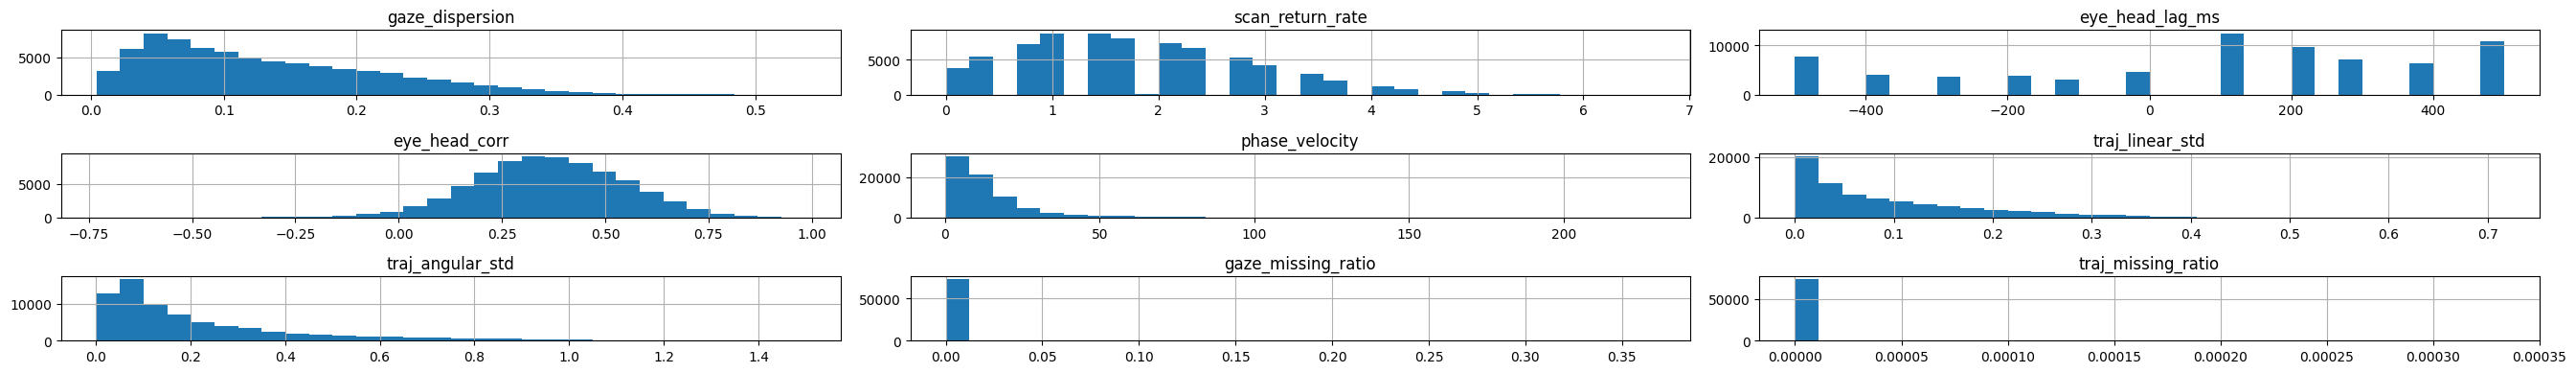

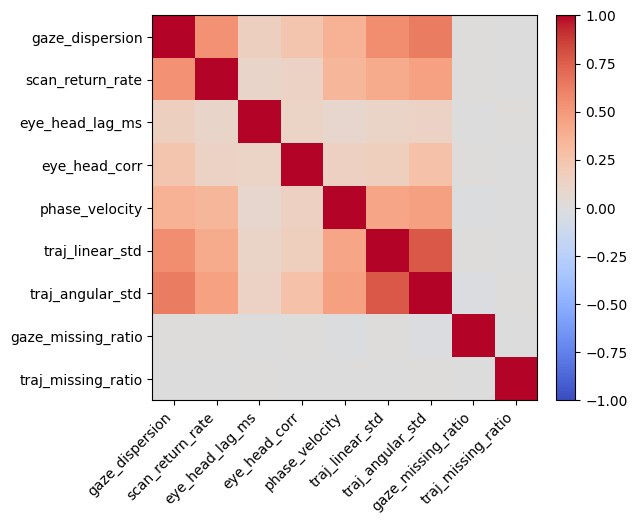

<Figure size 640x480 with 0 Axes>

In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stats_files = list((RUN_ROOT / 'windows').glob('*/stats.parquet'))
if not stats_files:
    print('No stats.parquet found under', RUN_ROOT / 'windows')
else:
    frames = []
    for fp in stats_files:
        df = pd.read_parquet(fp)
        if len(df) > 2000:
            df = df.sample(2000, random_state=42)
        df['take_uid'] = fp.parent.name
        frames.append(df)
    stats_df = pd.concat(frames, ignore_index=True)
    stats_sample_path = DATA_AUDIT_DIR / 'stats_sample.parquet'
    stats_df.to_parquet(stats_sample_path, index=False)
    print('Saved stats sample ->', stats_sample_path)
    feature_cols = [
        'gaze_dispersion',
        'scan_return_rate',
        'eye_head_lag_ms',
        'eye_head_corr',
        'phase_velocity',
        'traj_linear_std',
        'traj_angular_std',
        'gaze_missing_ratio',
        'traj_missing_ratio',
    ]
    existing_cols = [c for c in feature_cols if c in stats_df.columns]
    if existing_cols:
        stats_df[existing_cols].hist(bins=30, figsize=(len(existing_cols) * 3, 4))
        plt.tight_layout()
        plt.show()
        plt.savefig(DATA_AUDIT_DIR / 'feature_hist.png', dpi=150)
        plt.close()
        corr = stats_df[existing_cols].corr()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_xticks(range(len(existing_cols)))
        ax.set_xticklabels(existing_cols, rotation=45, ha='right')
        ax.set_yticks(range(len(existing_cols)))
        ax.set_yticklabels(existing_cols)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.show()
        plt.tight_layout()
        plt.savefig(DATA_AUDIT_DIR / 'feature_corr.png', dpi=150)
        plt.close(fig)
    else:
        print('No matching feature columns found in stats data.')


## 9. Assumed-normal & Proxy


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

stats_sample_path = DATA_AUDIT_DIR / 'stats_sample.parquet'
if not stats_sample_path.exists():
    print('stats_sample.parquet missing; run Section 8 first.')
else:
    stats_df = pd.read_parquet(stats_sample_path)
    viz_dir = DATA_AUDIT_DIR / 'assumed_normal'
    viz_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    if 'gaze_missing_ratio' in stats_df.columns:
        sns.histplot(stats_df['gaze_missing_ratio'], bins=30, ax=axes[0])
        axes[0].set_title('Gaze missing ratio (per-window)')
    if 'traj_missing_ratio' in stats_df.columns:
        sns.histplot(stats_df['traj_missing_ratio'], bins=30, ax=axes[1])
        axes[1].set_title('Trajectory missing ratio (per-window)')
    if 'eye_head_corr' in stats_df.columns:
        sns.histplot(stats_df['eye_head_corr'].dropna(), bins=30, ax=axes[2])
        axes[2].set_title('Eye-head correlation')
    plt.tight_layout()
    plt.savefig(viz_dir / 'assumed_normal_hist.png', dpi=150)
    plt.close(fig)

    feature_pairs = [
        ('gaze_missing_ratio', 'traj_missing_ratio'),
        ('gaze_missing_ratio', 'eye_head_corr'),
        ('eye_head_corr', 'phase_velocity'),
    ]
    for x_col, y_col in feature_pairs:
        if x_col not in stats_df.columns or y_col not in stats_df.columns:
            continue
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.scatterplot(x=stats_df[x_col], y=stats_df[y_col], s=5, ax=ax, alpha=0.3)
        ax.set_title(f'{x_col} vs {y_col}')
        plt.tight_layout()
        plt.savefig(viz_dir / f'scatter_{x_col}_{y_col}.png', dpi=150)
        plt.close(fig)

    thresholds = {}
    def percentile_threshold(series, percentile, default):
        if series.dropna().empty:
            return default
        return float(series.quantile(percentile))

    thresholds['gaze_missing_ratio'] = percentile_threshold(stats_df.get('gaze_missing_ratio', pd.Series()), 0.3, 0.4)
    thresholds['traj_missing_ratio'] = percentile_threshold(stats_df.get('traj_missing_ratio', pd.Series()), 0.3, 0.1)
    thresholds['eye_head_corr'] = percentile_threshold(stats_df.get('eye_head_corr', pd.Series()), 0.7, 0.0)

    print('Adaptive thresholds:', thresholds)
    mask = pd.Series(True, index=stats_df.index)
    if 'gaze_missing_ratio' in stats_df.columns:
        mask &= stats_df['gaze_missing_ratio'] <= thresholds['gaze_missing_ratio']
    if 'traj_missing_ratio' in stats_df.columns:
        mask &= stats_df['traj_missing_ratio'] <= thresholds['traj_missing_ratio']
    if 'eye_head_corr' in stats_df.columns:
        mask &= stats_df['eye_head_corr'] >= thresholds['eye_head_corr']

    selected = stats_df[mask].copy()
    total = len(stats_df)
    selected_len = len(selected)
    ratio = selected_len / total if total else 0
    summary_path = viz_dir / 'assumed_normal_stats.txt'
    summary = f"Total windows: {total}\nSelected: {selected_len}\nFraction: {ratio:.3f}\nThresholds: {thresholds}\n"
    summary_path.write_text(summary)
    print(summary)

    normal_df_path = DATA_AUDIT_DIR / 'windows_normal_sample.parquet'
    selected.to_parquet(normal_df_path, index=False)
    normal_out = RUN_ROOT / 'windows_normal.parquet'
    selected.to_parquet(normal_out, index=False)
    print(f'Saved assumed-normal windows -> {normal_out} ({selected_len} rows)')


Adaptive thresholds: {'gaze_missing_ratio': 0.00015999999999993797, 'traj_missing_ratio': 0.0, 'eye_head_corr': 0.4601926444188119}
Total windows: 73542
Selected: 21853
Fraction: 0.297
Thresholds: {'gaze_missing_ratio': 0.00015999999999993797, 'traj_missing_ratio': 0.0, 'eye_head_corr': 0.4601926444188119}

Saved assumed-normal windows -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/windows_normal.parquet (21853 rows)


### 9.1 Gaze Missing Ratio Diagnostics


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

stats_sample_path = DATA_AUDIT_DIR / 'stats_sample.parquet'
if not stats_sample_path.exists():
    print('stats_sample.parquet missing; run Section 8 first.')
else:
    stats_df = pd.read_parquet(stats_sample_path)
    if 'gaze_missing_ratio' in stats_df.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.violinplot(y=stats_df['gaze_missing_ratio'], ax=ax)
        ax.set_title('Gaze missing ratio distribution')
        plt.tight_layout()
        plt.savefig(DATA_AUDIT_DIR / 'assumed_normal/gaze_missing_violin.png', dpi=150)
        plt.close(fig)
    else:
        print('gaze_missing_ratio column missing; rerun windowing with feature_version >= v2')



=== Normal Filtering Statistics ===
Total windows: 73542
Selected (normal): 21853
Pass rate: 29.7%
Rejected: 51689 (70.3%)

=== Per-Take Statistics ===
Takes in dataset: 40
Takes with >0 normal windows: 40
Windows per take (all): mean=1839, std=408
Windows per take (normal): mean=546, std=169

=== Feature Distributions (Selected vs All) ===
gaze_missing_ratio       : all=0.001±0.009, selected=0.000±0.000, shift=-0.001
traj_missing_ratio       : all=0.000±0.000, selected=0.000±0.000, shift=-0.000
eye_head_corr            : all=0.362±0.184, selected=0.574±0.087, shift=+0.211


/var/folders/4z/hvk3zszd0ys3029345c617yc0000gn/T/ipykernel_78380/2842609042.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['All', 'Selected'], patch_artist=True)
/var/folders/4z/hvk3zszd0ys3029345c617yc0000gn/T/ipykernel_78380/2842609042.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['All', 'Selected'], patch_artist=True)
/var/folders/4z/hvk3zszd0ys3029345c617yc0000gn/T/ipykernel_78380/2842609042.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['All', 'Selected'], patch_artist=True)


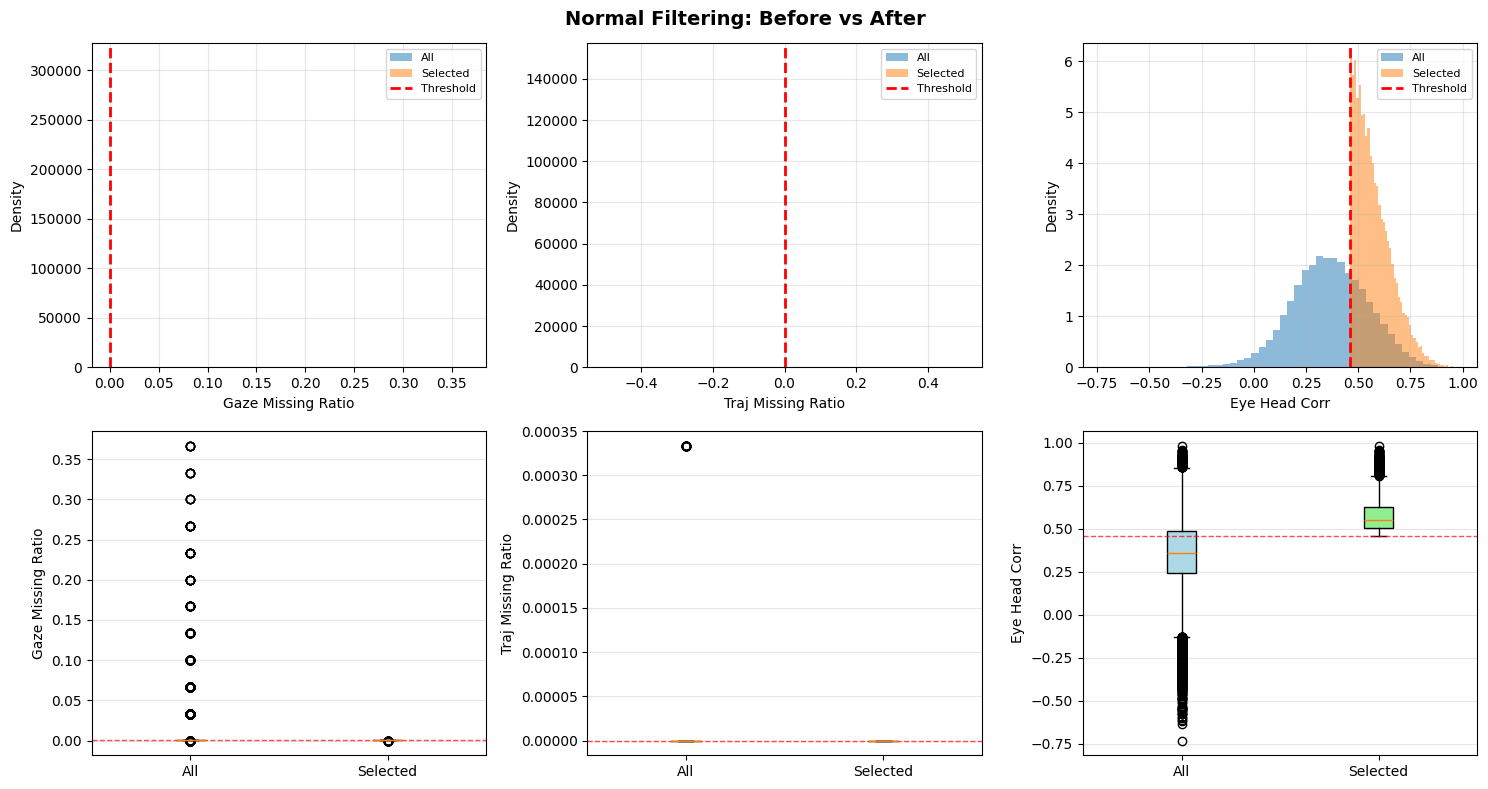


✅ Saved filtering comparison -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/assumed_normal/filtering_before_after.png


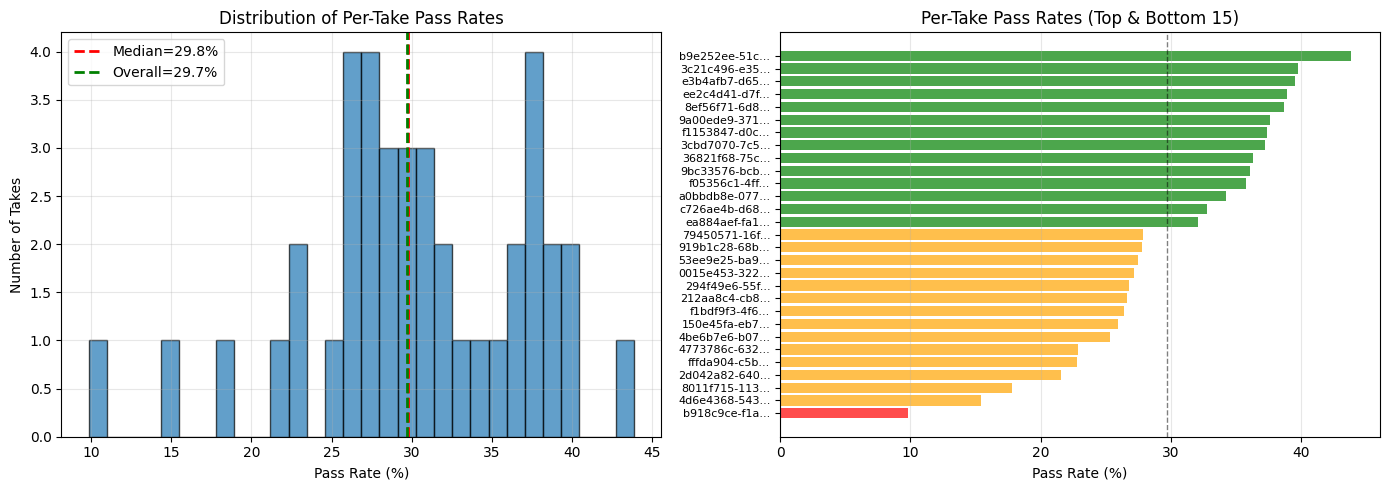

✅ Saved per-take analysis -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/assumed_normal/per_take_pass_rates.png

=== Threshold Sensitivity Analysis ===
  P20:  19.8% pass (14567 windows)
  P30:  29.7% pass (21853 windows)
  P40:  39.6% pass (29140 windows)
  P50:  49.5% pass (36416 windows)
  P60:  59.4% pass (43686 windows)
  P70:  69.3% pass (50982 windows)


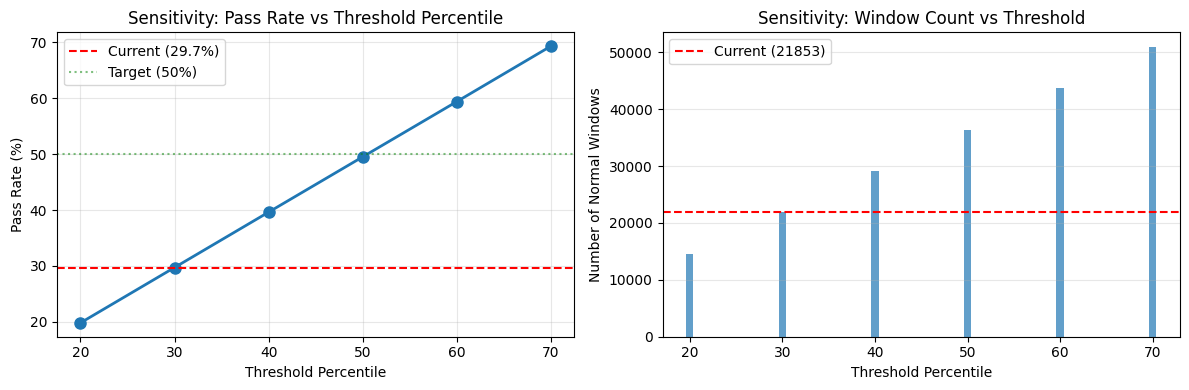

✅ Saved sensitivity analysis -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/assumed_normal/threshold_sensitivity.png

NORMAL FILTERING COMPLETE


In [23]:
# === Enhanced Visualization: Filtering Analysis ===

import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== Normal Filtering Statistics ===")
print(f"Total windows: {total}")
print(f"Selected (normal): {selected_len}")
print(f"Pass rate: {ratio*100:.1f}%")
print(f"Rejected: {total - selected_len} ({(1-ratio)*100:.1f}%)")

# Per-take breakdown
if 'take_uid' in selected.columns:
    per_take_all = stats_df.groupby('take_uid').size()
    per_take_selected = selected.groupby('take_uid').size()

    print(f"\n=== Per-Take Statistics ===")
    print(f"Takes in dataset: {len(per_take_all)}")
    print(f"Takes with >0 normal windows: {len(per_take_selected)}")
    print(f"Windows per take (all): mean={per_take_all.mean():.0f}, std={per_take_all.std():.0f}")
    print(f"Windows per take (normal): mean={per_take_selected.mean():.0f}, std={per_take_selected.std():.0f}")

    # Takes with very few normal windows (potential issues)
    low_takes = per_take_selected[per_take_selected < 20]
    if len(low_takes) > 0:
        print(f"\n⚠️  Warning: {len(low_takes)} takes have <20 normal windows:")
        for uid, count in low_takes.items():
            print(f"  {uid[:8]}...: {count} windows")

# Feature distribution comparison
print("\n=== Feature Distributions (Selected vs All) ===")
comparison_data = []
for col in ['gaze_missing_ratio', 'traj_missing_ratio', 'eye_head_corr']:
    if col in stats_df.columns:
        all_mean = stats_df[col].mean()
        all_std = stats_df[col].std()
        sel_mean = selected[col].mean()
        sel_std = selected[col].std()
        comparison_data.append({
            'feature': col,
            'all_mean': all_mean,
            'all_std': all_std,
            'selected_mean': sel_mean,
            'selected_std': sel_std,
            'shift': sel_mean - all_mean
        })
        print(f"{col:25s}: all={all_mean:.3f}±{all_std:.3f}, selected={sel_mean:.3f}±{sel_std:.3f}, shift={sel_mean-all_mean:+.3f}")

# Visualization 1: Before/After distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Normal Filtering: Before vs After', fontsize=14, fontweight='bold')

filter_features = ['gaze_missing_ratio', 'traj_missing_ratio', 'eye_head_corr']
for idx, col in enumerate(filter_features):
    if col not in stats_df.columns:
        continue

    # Top row: Histograms
    ax = axes[0, idx]
    ax.hist(stats_df[col].dropna(), bins=50, alpha=0.5, label='All', density=True)
    ax.hist(selected[col].dropna(), bins=50, alpha=0.5, label='Selected', density=True)
    ax.axvline(thresholds.get(col, 0), color='r', linestyle='--', linewidth=2, label='Threshold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Bottom row: Boxplots
    ax = axes[1, idx]
    data_to_plot = [stats_df[col].dropna(), selected[col].dropna()]
    bp = ax.boxplot(data_to_plot, labels=['All', 'Selected'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightgreen')
    ax.axhline(thresholds.get(col, 0), color='r', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(viz_dir / 'filtering_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved filtering comparison -> {viz_dir / 'filtering_before_after.png'}")

# Visualization 2: Per-take pass rate
if 'take_uid' in selected.columns:
    per_take_ratio = (per_take_selected / per_take_all * 100).fillna(0).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Histogram of pass rates
    axes[0].hist(per_take_ratio, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(per_take_ratio.median(), color='r', linestyle='--',
                    linewidth=2, label=f'Median={per_take_ratio.median():.1f}%')
    axes[0].axvline(ratio*100, color='g', linestyle='--',
                    linewidth=2, label=f'Overall={ratio*100:.1f}%')
    axes[0].set_xlabel('Pass Rate (%)')
    axes[0].set_ylabel('Number of Takes')
    axes[0].set_title('Distribution of Per-Take Pass Rates')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: Top/Bottom takes
    n_show = min(15, len(per_take_ratio))
    combined = pd.concat([
        per_take_ratio.head(n_show),
        per_take_ratio.tail(n_show)
    ]).drop_duplicates()

    colors = ['red' if x < ratio*100*0.5 else 'orange' if x < ratio*100 else 'green'
              for x in combined.values]

    axes[1].barh(range(len(combined)), combined.values, color=colors, alpha=0.7)
    axes[1].set_yticks(range(len(combined)))
    axes[1].set_yticklabels([uid[:12]+'...' for uid in combined.index], fontsize=8)
    axes[1].set_xlabel('Pass Rate (%)')
    axes[1].set_title(f'Per-Take Pass Rates (Top & Bottom {n_show})')
    axes[1].axvline(ratio*100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(viz_dir / 'per_take_pass_rates.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved per-take analysis -> {viz_dir / 'per_take_pass_rates.png'}")

# Visualization 3: Threshold sensitivity analysis
print("\n=== Threshold Sensitivity Analysis ===")
percentiles_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
sensitivity_results = []

for p in percentiles_to_test:
    test_thresholds = {
        'gaze_missing_ratio': percentile_threshold(stats_df.get('gaze_missing_ratio', pd.Series()), p, 0.4),
        'traj_missing_ratio': percentile_threshold(stats_df.get('traj_missing_ratio', pd.Series()), p, 0.1),
        'eye_head_corr': percentile_threshold(stats_df.get('eye_head_corr', pd.Series()), 1-p, 0.0),
    }

    test_mask = pd.Series(True, index=stats_df.index)
    if 'gaze_missing_ratio' in stats_df.columns:
        test_mask &= stats_df['gaze_missing_ratio'] <= test_thresholds['gaze_missing_ratio']
    if 'traj_missing_ratio' in stats_df.columns:
        test_mask &= stats_df['traj_missing_ratio'] <= test_thresholds['traj_missing_ratio']
    if 'eye_head_corr' in stats_df.columns:
        test_mask &= stats_df['eye_head_corr'] >= test_thresholds['eye_head_corr']

    test_selected = stats_df[test_mask]
    pass_rate = len(test_selected) / len(stats_df) * 100

    sensitivity_results.append({
        'percentile': p,
        'pass_rate': pass_rate,
        'n_windows': len(test_selected)
    })
    print(f"  P{int(p*100):02d}: {pass_rate:5.1f}% pass ({len(test_selected):5d} windows)")

sensitivity_df = pd.DataFrame(sensitivity_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Pass rate vs percentile
axes[0].plot(sensitivity_df['percentile']*100, sensitivity_df['pass_rate'],
             marker='o', linewidth=2, markersize=8)
axes[0].axhline(ratio*100, color='r', linestyle='--', label=f'Current ({ratio*100:.1f}%)')
axes[0].axhline(50, color='g', linestyle=':', alpha=0.5, label='Target (50%)')
axes[0].set_xlabel('Threshold Percentile')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_title('Sensitivity: Pass Rate vs Threshold Percentile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Number of windows
axes[1].bar(sensitivity_df['percentile']*100, sensitivity_df['n_windows'], alpha=0.7)
axes[1].axhline(selected_len, color='r', linestyle='--', label=f'Current ({selected_len})')
axes[1].set_xlabel('Threshold Percentile')
axes[1].set_ylabel('Number of Normal Windows')
axes[1].set_title('Sensitivity: Window Count vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(viz_dir / 'threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved sensitivity analysis -> {viz_dir / 'threshold_sensitivity.png'}")

print("\n" + "="*60)
print("NORMAL FILTERING COMPLETE")
print("="*60)

## 10. Split Suggestions


In [24]:

import pandas as pd
coverage_path = DATA_AUDIT_DIR / 'coverage_summary.csv'
if not coverage_path.exists():
    print('coverage_summary.csv missing; run Section 7 first.')
else:
    coverage_df = pd.read_csv(coverage_path)
    if 'take_name' in coverage_df.columns:
        coverage_df['wearer'] = coverage_df['take_name'].str.extract(r'(^[^_]+_[^_]+)')
    else:
        coverage_df['wearer'] = coverage_df['take_uid'].str[:8]
    coverage_df = coverage_df.sort_values('take_uid').reset_index(drop=True)
    splits = ['train', 'val', 'test']
    split_sizes = [0.7, 0.15, 0.15]
    assignments = []
    total = len(coverage_df)
    boundaries = [int(total * split_sizes[0]), int(total * sum(split_sizes[:2]))]
    for idx in range(total):
        if idx < boundaries[0]:
            assignments.append('train')
        elif idx < boundaries[1]:
            assignments.append('val')
        else:
            assignments.append('test')
    coverage_df['split'] = assignments
    split_out = DATA_AUDIT_DIR / 'split_suggestion.csv'
    coverage_df.to_csv(split_out, index=False)
    print('Saved split suggestion ->', split_out)


Saved split suggestion -> /Users/huangjunda/Desktop/MIT 2.156/Final Project/runs/20251111_10scenario/notebook_reports/data_audit/split_suggestion.csv
